# Phase 1 Data Audit

This notebook inspects Phase 1 ingestion outputs only.

Rules:

1. No downloading.
2. No data cleaning.
3. No production logic.
4. No realised variance, VRP, regimes, or backtests.
5. If any reusable logic is needed, move it into `src/vrp/` and add tests.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

## Expected Phase 1 Outputs

In [2]:
ROOT = Path("..").resolve()

AUDIT_PATH = ROOT / "reports" / "tables" / "data_audit.csv"

PROCESSED_PATHS = {
    "us_vix": ROOT / "data" / "processed" / "us_vix.parquet",
    "us_underlying": ROOT / "data" / "processed" / "us_underlying.parquet",
    "india_vix": ROOT / "data" / "processed" / "india_vix.parquet",
    "india_underlying": ROOT / "data" / "processed" / "india_underlying.parquet",
}

RAW_PATHS = {
    "us_vix_cboe": ROOT / "data" / "raw" / "us_vix_cboe.parquet",
    "us_vix_fred": ROOT / "data" / "raw" / "us_vix_fred.parquet",
    "us_vix_yahoo": ROOT / "data" / "raw" / "us_vix_yahoo.parquet",
    "us_spx_yahoo": ROOT / "data" / "raw" / "us_spx_yahoo.parquet",
    "us_spy_yahoo": ROOT / "data" / "raw" / "us_spy_yahoo.parquet",
    "india_vix_yahoo": ROOT / "data" / "raw" / "india_vix_yahoo.parquet",
    "india_nifty_yahoo": ROOT / "data" / "raw" / "india_nifty_yahoo.parquet",
}

print("Audit path:", AUDIT_PATH)
print("\nProcessed paths:")
for name, path in PROCESSED_PATHS.items():
    print(f"{name:20s} exists={path.exists()} path={path}")

print("\nRaw paths:")
for name, path in RAW_PATHS.items():
    print(f"{name:20s} exists={path.exists()} path={path}")

Audit path: C:\Users\daksh\Desktop\EPAT\EPAT_Project_VRP_Regime\reports\tables\data_audit.csv

Processed paths:
us_vix               exists=True path=C:\Users\daksh\Desktop\EPAT\EPAT_Project_VRP_Regime\data\processed\us_vix.parquet
us_underlying        exists=True path=C:\Users\daksh\Desktop\EPAT\EPAT_Project_VRP_Regime\data\processed\us_underlying.parquet
india_vix            exists=True path=C:\Users\daksh\Desktop\EPAT\EPAT_Project_VRP_Regime\data\processed\india_vix.parquet
india_underlying     exists=True path=C:\Users\daksh\Desktop\EPAT\EPAT_Project_VRP_Regime\data\processed\india_underlying.parquet

Raw paths:
us_vix_cboe          exists=True path=C:\Users\daksh\Desktop\EPAT\EPAT_Project_VRP_Regime\data\raw\us_vix_cboe.parquet
us_vix_fred          exists=True path=C:\Users\daksh\Desktop\EPAT\EPAT_Project_VRP_Regime\data\raw\us_vix_fred.parquet
us_vix_yahoo         exists=True path=C:\Users\daksh\Desktop\EPAT\EPAT_Project_VRP_Regime\data\raw\us_vix_yahoo.parquet
us_spx_yahoo      

## Data Audit Table

In [3]:
audit = pd.read_csv(AUDIT_PATH)
audit

,market,dataset,source,symbol,start_date,end_date,n_rows,n_missing_close,n_duplicate_dates,min_close,max_close,validation_status
0,US,us_vix,fred_vixcls,VIXCLS,1990-01-02,2026-05-14,9186,0,0,9.14,82.69,PASS


## Validation Failures, If Any

In [4]:
failures = audit[~audit["validation_status"].astype(str).str.startswith("PASS")]
failures

,market,dataset,source,symbol,start_date,end_date,n_rows,n_missing_close,n_duplicate_dates,min_close,max_close,validation_status


## Load Processed Datasets

In [5]:
processed = {name: pd.read_parquet(path) for name, path in PROCESSED_PATHS.items()}

for name, df in processed.items():
    print("=" * 80)
    print(name)
    print(df.shape)
    display(df.head())
    display(df.tail())

us_vix
(9186, 10)


,date,open,high,low,close,adj_close,volume,source,market,symbol
0,1990-01-02,17.24,17.24,17.24,17.24,17.24,0,fred_vixcls,US,VIXCLS
1,1990-01-03,18.19,18.19,18.19,18.19,18.19,0,fred_vixcls,US,VIXCLS
2,1990-01-04,19.22,19.22,19.22,19.22,19.22,0,fred_vixcls,US,VIXCLS
3,1990-01-05,20.11,20.11,20.11,20.11,20.11,0,fred_vixcls,US,VIXCLS
4,1990-01-08,20.26,20.26,20.26,20.26,20.26,0,fred_vixcls,US,VIXCLS


,date,open,high,low,close,adj_close,volume,source,market,symbol
9181,2026-05-08,17.19,17.19,17.19,17.19,17.19,0,fred_vixcls,US,VIXCLS
9182,2026-05-11,18.38,18.38,18.38,18.38,18.38,0,fred_vixcls,US,VIXCLS
9183,2026-05-12,17.99,17.99,17.99,17.99,17.99,0,fred_vixcls,US,VIXCLS
9184,2026-05-13,17.87,17.87,17.87,17.87,17.87,0,fred_vixcls,US,VIXCLS
9185,2026-05-14,17.26,17.26,17.26,17.26,17.26,0,fred_vixcls,US,VIXCLS


us_underlying
(9160, 10)


,date,open,high,low,close,adj_close,volume,source,market,symbol
0,1990-01-02,353.399994,359.690002,351.980011,359.690002,359.690002,162070000,yahoo_spx,US,^GSPC
1,1990-01-03,359.690002,360.589996,357.890015,358.760010,358.760010,192330000,yahoo_spx,US,^GSPC
2,1990-01-04,358.760010,358.760010,352.890015,355.670013,355.670013,177000000,yahoo_spx,US,^GSPC
3,1990-01-05,355.670013,355.670013,351.350006,352.200012,352.200012,158530000,yahoo_spx,US,^GSPC
4,1990-01-08,352.200012,354.239990,350.540009,353.790009,353.790009,140110000,yahoo_spx,US,^GSPC


...

,date,open,high,low,close,adj_close,volume,source,market,symbol
0,2009-03-02,40.610001,44.779999,40.610001,43.360001,43.360001,0,yahoo_india_vix,INDIA,^INDIAVIX
1,2009-03-03,43.360001,44.549999,41.840000,44.439999,44.439999,0,yahoo_india_vix,INDIA,^INDIAVIX
2,2009-03-04,44.439999,44.439999,42.450001,42.770000,42.770000,0,yahoo_india_vix,INDIA,^INDIAVIX
3,2009-03-05,42.770000,49.730000,41.400002,41.560001,41.560001,0,yahoo_india_vix,INDIA,^INDIAVIX
4,2009-03-06,41.560001,41.580002,37.500000,37.970001,37.970001,0,yahoo_india_vix,INDIA,^INDIAVIX


,date,open,high,low,close,adj_close,volume,source,market,symbol
4215,2026-05-11,16.840000,18.969999,16.840000,18.549999,18.549999,0,yahoo_india_vix,INDIA,^INDIAVIX
4216,2026-05-12,18.549999,19.459999,17.629999,19.280001,19.280001,0,yahoo_india_vix,INDIA,^INDIAVIX
4217,2026-05-13,19.280001,20.129999,18.360001,19.430000,19.430000,0,yahoo_india_vix,INDIA,^INDIAVIX
4218,2026-05-14,19.430000,19.430000,18.389999,18.610001,18.610001,0,yahoo_india_vix,INDIA,^INDIAVIX
4219,2026-05-15,18.610001,19.010000,17.420000,18.790001,18.790001,0,yahoo_india_vix,INDIA,^INDIAVIX


india_underlying
(4576, 10)


,date,open,high,low,close,adj_close,volume,source,market,symbol
0,2007-09-17,4518.450195,4549.049805,4482.850098,4494.649902,4494.649902,0,yahoo_nifty,INDIA,^NSEI
1,2007-09-18,4494.100098,4551.799805,4481.549805,4546.200195,4546.200195,0,yahoo_nifty,INDIA,^NSEI
2,2007-09-19,4550.250000,4739.000000,4550.250000,4732.350098,4732.350098,0,yahoo_nifty,INDIA,^NSEI
3,2007-09-20,4734.850098,4760.850098,4721.149902,4747.549805,4747.549805,0,yahoo_nifty,INDIA,^NSEI
4,2007-09-21,4752.950195,4855.700195,4733.700195,4837.549805,4837.549805,0,yahoo_nifty,INDIA,^NSEI


,date,open,high,low,close,adj_close,volume,source,market,symbol
4571,2026-05-11,23970.099609,23997.449219,23799.099609,23815.849609,23815.849609,390100,yahoo_nifty,INDIA,^NSEI
4572,2026-05-12,23722.599609,23757.550781,23348.400391,23379.550781,23379.550781,447500,yahoo_nifty,INDIA,^NSEI
4573,2026-05-13,23362.449219,23582.949219,23262.550781,23412.599609,23412.599609,415400,yahoo_nifty,INDIA,^NSEI
4574,2026-05-14,23530.250000,23777.199219,23426.550781,23689.599609,23689.599609,428700,yahoo_nifty,INDIA,^NSEI
4575,2026-05-15,23731.400391,23839.300781,23610.300781,23643.500000,23643.500000,408900,yahoo_nifty,INDIA,^NSEI


## Canonical Schema Check

In [6]:
CANONICAL_COLUMNS = [
    "date",
    "open",
    "high",
    "low",
    "close",
    "adj_close",
    "volume",
    "source",
    "market",
    "symbol",
]

schema_rows = []
for name, df in processed.items():
    schema_rows.append(
        {
            "dataset": name,
            "columns_match_exactly": list(df.columns) == CANONICAL_COLUMNS,
            "columns": list(df.columns),
        }
    )

pd.DataFrame(schema_rows)

,dataset,columns_match_exactly,columns
0,us_vix,True,"[date, open, high, low, close, adj_close, volu..."
1,us_underlying,True,"[date, open, high, low, close, adj_close, volu..."
2,india_vix,True,"[date, open, high, low, close, adj_close, volu..."
3,india_underlying,True,"[date, open, high, low, close, adj_close, volu..."


## Missingness Summary

In [7]:
missing_rows = []
for name, df in processed.items():
    for column in df.columns:
        missing_rows.append(
            {
                "dataset": name,
                "column": column,
                "n_missing": int(df[column].isna().sum()),
                "missing_fraction": float(df[column].isna().mean()),
            }
        )

missing_summary = pd.DataFrame(missing_rows)
missing_summary[missing_summary["n_missing"] > 0]

,dataset,column,n_missing,missing_fraction


## Date Ranges

In [8]:
date_rows = []
for name, df in processed.items():
    dates = pd.to_datetime(df["date"], errors="coerce")
    date_rows.append(
        {
            "dataset": name,
            "source": df["source"].dropna().unique().tolist(),
            "market": df["market"].dropna().unique().tolist(),
            "symbol": df["symbol"].dropna().unique().tolist(),
            "start_date": dates.min(),
            "end_date": dates.max(),
            "n_rows": len(df),
            "n_unique_dates": df["date"].nunique(),
        }
    )

pd.DataFrame(date_rows)

,dataset,source,market,symbol,start_date,end_date,n_rows,n_unique_dates
0,us_vix,[fred_vixcls],[US],[VIXCLS],1990-01-02,2026-05-14,9186,9186
1,us_underlying,[yahoo_spx],[US],[^GSPC],1990-01-02,2026-05-15,9160,9160
2,india_vix,[yahoo_india_vix],[INDIA],[^INDIAVIX],2009-03-02,2026-05-15,4220,4220
3,india_underlying,[yahoo_nifty],[INDIA],[^NSEI],2007-09-17,2026-05-15,4576,4576


## Close-Series Visual Check

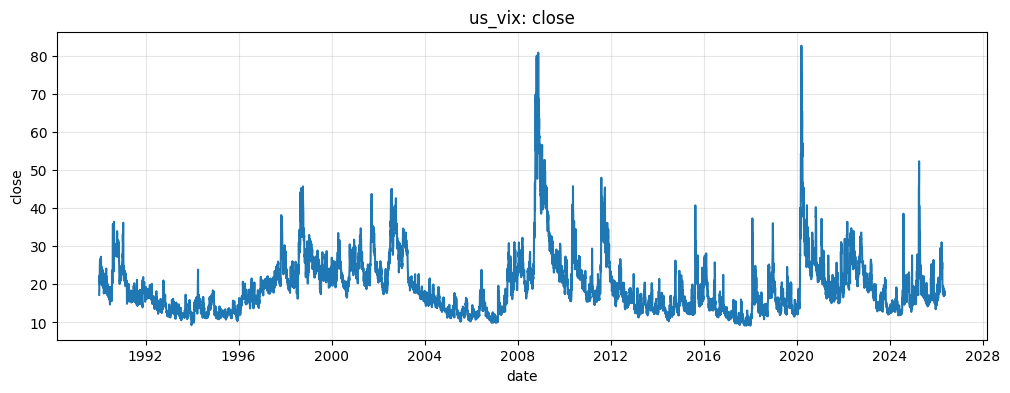

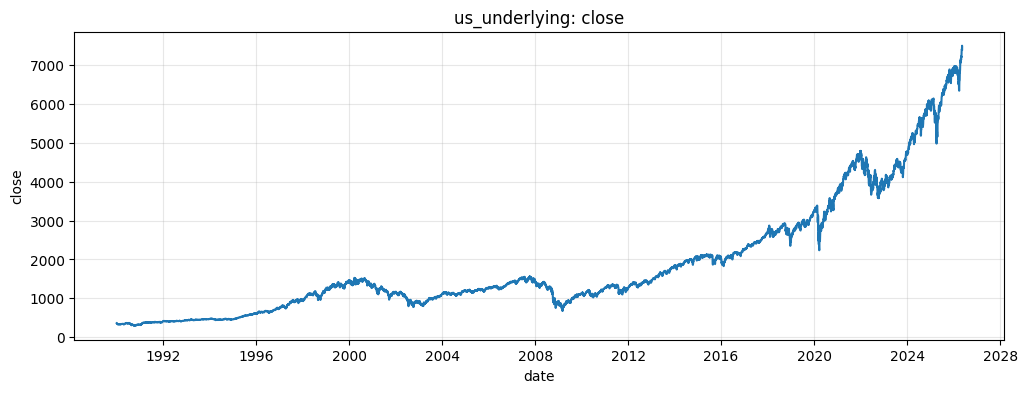

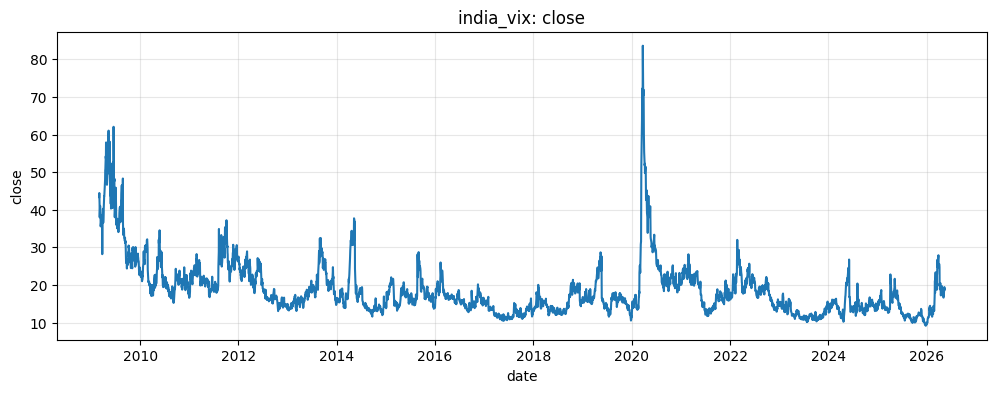

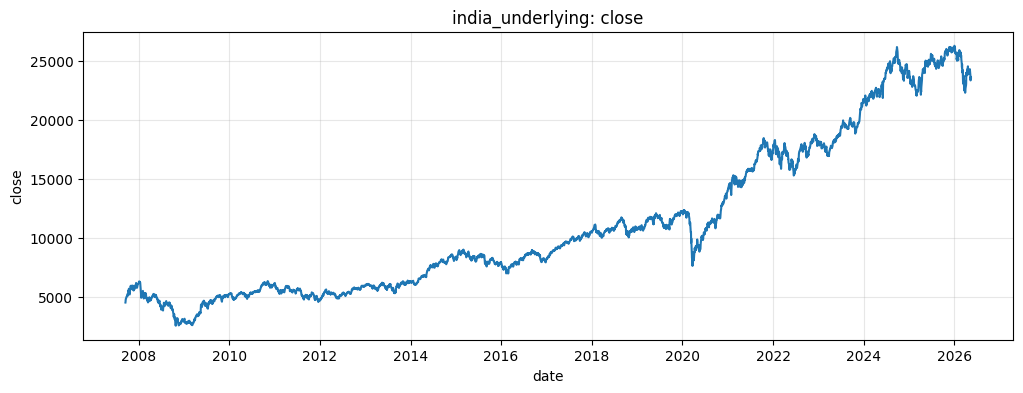

In [9]:
for name, df in processed.items():
    plot_df = df.copy()
    plot_df["date"] = pd.to_datetime(plot_df["date"], errors="coerce")
    plot_df = plot_df.sort_values("date")

    plt.figure(figsize=(12, 4))
    plt.plot(plot_df["date"], plot_df["close"])
    plt.title(f"{name}: close")
    plt.xlabel("date")
    plt.ylabel("close")
    plt.grid(True, alpha=0.3)
    plt.show()

## Audit Notes

Manual checks to record after running this notebook:

- Do the four processed datasets exist?
- Does each processed dataset follow canonical schema?
- Are date ranges plausible?
- Are any validation failures present in `data_audit.csv`?
- Are there missing close values?
- Are close plots visually reasonable?
- Are source labels explicit and not silently mixed?